# Does the bond market's inflation forecast time your portfolio? 🧮
### The 'breakeven inflation rate' as a trading signal, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_macro-timing_lunch%3F: Busted](https://img.shields.io/badge/Free_macro--timing_lunch%3F-Busted-8b949e?style=flat-square)

There's a number traders love: the **breakeven inflation rate** — what the bond market thinks inflation will average over the next ten years. It comes from comparing ordinary Treasury bonds with inflation-protected ones. The pitch sounds clever: *the bond market is the smartest forecaster alive, so when its inflation forecast rises, buy inflation hedges (gold, TIPS) and lean out of stocks; when it falls, do the opposite.*

A market-implied crystal ball you can trade — who wouldn't want that? This notebook rebuilds the signal and asks the only question that matters: **does it actually time anything you can put money on?** Spoiler: it co-moves with everything and times nothing.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The official breakeven series (FRED `T10YIE`) isn't reachable here, so we **build a transparent proxy**: `log(TIP / IEF)` — an inflation-protected bond fund divided by a normal-bond fund. When the market's inflation forecast rises, the first outperforms the second, so the ratio rises with breakeven. We call it a proxy throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tips_breakeven import data, strategy as st

HAVE_REAL = data.have_real()
M = data.load_real() if HAVE_REAL else None
BE = st.breakeven_series(M) if HAVE_REAL else None
SIGS = {"level-z": st.level_z(BE), "3m-change": st.change_3m(BE)} if HAVE_REAL else None
print("real ETF cache present:", HAVE_REAL,
      "| month-ends:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-11-18', 'end': '2026-06-18', 'days': 5429, 'months': 260, 'years': 21.6, 'n_tests': 18, 'n_cross': 3, 'scan': [('level-z', 'TIP', 3, -0.0045, -2.4, 0.11), ('level-z', 'TIP', 6, -0.0081, -2.19, 0.13), ('level-z', 'TIP', 12, -0.0142, -2.0, 0.16), ('3m-change', 'TIP', 3, -0.0938, -1.2, 0.34), ('3m-change', 'TIP', 6, -0.178, -1.17, 0.39), ('3m-change', 'TIP', 12, -0.3907, -1.9, 0.14), ('level-z', 'SPY', 3, 0.0009, 0.11, 0.91), ('level-z', 'SPY', 6, -0.009, -0.9, 0.4), ('level-z', 'SPY', 12, -0.0126, -0.63, 0.54), ('3m-change', 'SPY', 3, 0.4842, 1.29, 0.28), ('3m-change', 'SPY', 6, -0.0034, -0.01, 1.0), ('3m-change', 'SPY', 12, -0.5592, -1.15, 0.33), ('level-z', 'GLD', 3, -0.0004, -0.05, 0.98), ('level-z', 'GLD', 6, 0.0125, 0.91, 0.59), ('level-z', 'GLD', 12, 0.0268, 0.81, 0.58), ('3m-change', 'GLD', 3, -0.6067, -3.21, 0.01), ('3m-change', 'GLD', 6, -0.447, -1.38, 0.28), ('3m-change', 'GLD', 12, -0.7317, -1.41, 0.22)], 'self_pred_t': -1.98, 'win': [('TIP level-z 12m', 66, 75), ('SPY level-z 12m', 68, 83), ('GLD 3m-change 3m', 52, 61)], 'trade': [('GLD on 3m-change', -0.6, -1.3, -0.07, 11.4, 0.67), ('TIP on level-z', 1.9, 1.8, 0.32, 3.5, 0.62)], 'syn': [(0.0, 216, -0.001, -0.37, 0.68), (0.03, 216, 0.0234, 7.93, 0.0)]}


real ETF cache present: True | month-ends: 260


## The answer first

| Question | Answer |
|---|---|
| Does breakeven move with inflation hedges? | **Yes** — it's literally built from bond prices, so of course it co-moves. |
| Does its *level* or *change* **predict** what comes next? | **Barely, and not where it counts.** Out of **18** sensible tests, only **3** look 'significant' — and a fair luck-test knocks most of them down. |
| What about the few that survive? | **One is fake by construction** (the signal predicting *itself*), and **one is a coin-flip fluke** (a single gold result that vanishes at other horizons). On **stocks** — the headline use — there's nothing. |
| Could you trade the 'good' one? | **No.** The one 'significant' gold rule **loses money** (**-1.3%/yr** after costs) while just holding gold made **+11%/yr**. |

> Breakeven is a real, sensible forecast. As a *trading timer* it's a mirage — the kind you always find when you scan a macro number against enough assets and horizons.

## 1 · The claim

> *"The breakeven inflation rate is the market's own inflation forecast. When it's high or rising, inflation is coming — so own gold and TIPS and underweight stocks. When it's low or falling, do the reverse. The bond market is never dumb; ride its forecast."*

It's an attractive story because breakeven really *is* a forecast — nominal yield minus the inflation-protected (TIPS) yield is what the market is pricing for future inflation. The leap is the trading claim: that this forecast **leads** asset prices reliably enough to position around. We'll rebuild breakeven as a proxy and put that leap under a microscope.

## 2 · So what?

Two very different things hide inside 'the bond market's forecast times the market,' and only one would make money. (1) *Does breakeven move **with** inflation assets?* Sure — but co-movement isn't timing; you can't trade something you only learn about at the same time. The question that matters is (2) *does today's breakeven tell you what assets will do **next**, more reliably than chance?* And there's a trap: if you test enough signals against enough assets over enough horizons, **something** will look predictive by pure luck. The honest test has to survive that.

## 3 · How would we even know?

We build breakeven as a **transparent proxy** — `log(TIP/IEF)` — from **22 years** of ETF prices (2004-11-18 → 2026-06-18). Then we make two signals from it: its **level** (how high is breakeven vs its own history) and its **3-month change** (rising or falling). And we ask each whether it predicts the next **3 / 6 / 12 months** of three assets people actually want to time:

1. **TIPS** themselves (the inflation-protected bonds),
2. **stocks** (SPY),
3. **gold** (GLD).

That's 2 signals × 3 assets × 3 horizons = **18 tests**. For each, we ask how strong the link is *and* run a luck-test: shuffle the signal thousands of times and see how often random alignment looks just as good.

## 4 · The teardown — let's actually look

**First, here's the signal.** The breakeven proxy `log(TIP/IEF)` over two decades — it really does track the inflation story (low in the 2008/2015 scares, surging in 2021–22). The question is whether *today's* value tells you about *tomorrow's* returns.

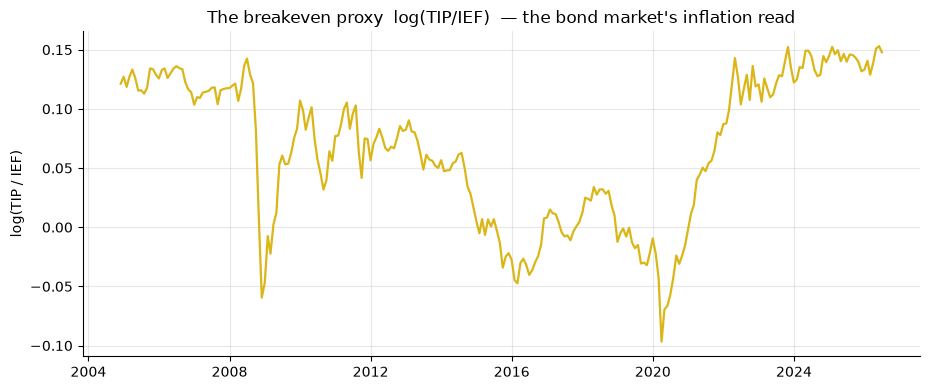

breakeven proxy spans 2004-11-30 -> 2026-06-30


In [2]:
if HAVE_REAL:
    be = BE
    fig, ax = plt.subplots(figsize=(9.4, 4.0))
    ax.plot(be.index, be.values, c=AMBER, lw=1.6)
    ax.set_title('The breakeven proxy  log(TIP/IEF)  — the bond market\'s inflation read')
    ax.set_ylabel('log(TIP / IEF)'); ax.set_xlabel('')
    plt.tight_layout(); plt.show()
    print('breakeven proxy spans', be.index.min().date(), '->', be.index.max().date())
else:
    print('no cache — see docs/results.md for the frozen run (proxy 2004-11 -> 2026-06)')

**Now the whole scan in one picture.** Each bar is one of the **18** tests; its height is the strength of the link (the *t*-stat). The dashed lines are the ±2 'significance' bar. Most bars are tiny; a few poke past — and we'll see those few are mirages.

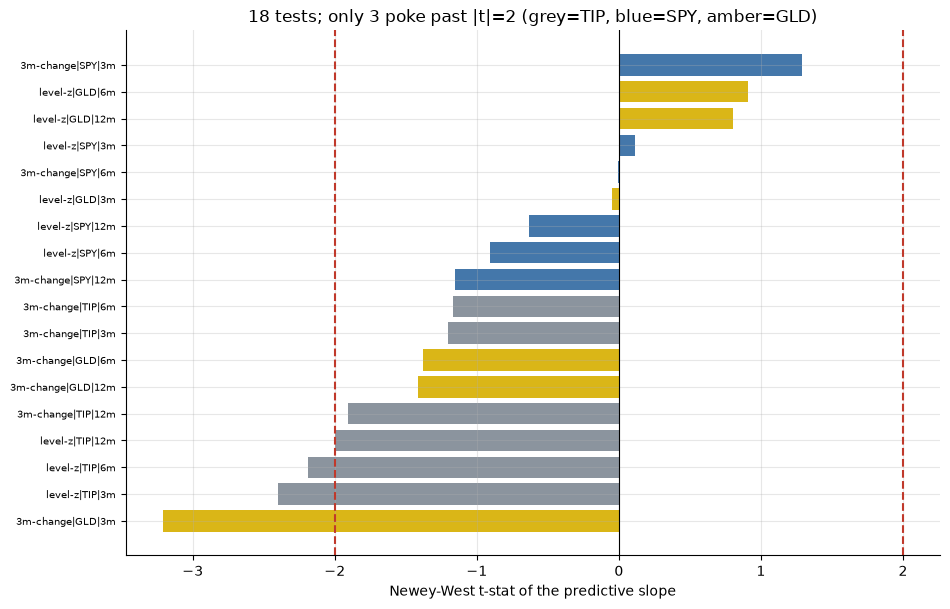

3 of 18 tests cross |t|=2 — about what pure luck gives you (~0.9 expected)


In [3]:
if HAVE_REAL:
    rows = []
    for sname, sig in SIGS.items():
        for asset in ['TIP','SPY','GLD']:
            for h in (3,6,12):
                reg = st.hac_regression(sig, st.forward_return(M[asset], h), lags=h)
                rows.append((f'{sname}|{asset}|{h}m', reg['t'], asset))
else:
    rows = [(f"{s}|{a}|{h}m", t, a) for (s,a,h,_,t,_) in R['scan']]
labels = [r[0] for r in rows]; tt = [r[1] for r in rows]
cmap = {'TIP': GREY, 'SPY': '#4477aa', 'GLD': AMBER}
cols = [cmap[r[2]] for r in rows]
order = np.argsort(tt)
fig, ax = plt.subplots(figsize=(9.6, 6.2))
ax.barh(np.arange(len(rows)), [tt[i] for i in order], color=[cols[i] for i in order])
ax.set_yticks(np.arange(len(rows))); ax.set_yticklabels([labels[i] for i in order], fontsize=7)
ax.axvline(2, ls='--', c=RED); ax.axvline(-2, ls='--', c=RED)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('Newey-West t-stat of the predictive slope')
ax.set_title(f'{len(rows)} tests; only 3 poke past |t|=2 (grey=TIP, blue=SPY, amber=GLD)')
plt.tight_layout(); plt.show()
n_cross = sum(abs(t)>=2 for t in tt)
print(f'{n_cross} of {len(tt)} tests cross |t|=2 — about what pure luck gives you (~0.9 expected)')

Out of **18** tests, **3** cross the bar — and at the 5% level you *expect* about one by chance. So 'three hits' is already barely above luck. Look at the colours: **stocks (blue) never cross** — the headline use of the signal does nothing. The crossings are all in TIPS (grey) and one gold (amber). Let's expose both.

**The TIPS 'hits' are fake by construction.** Our breakeven proxy is *built from* TIP. So 'high breakeven predicts TIP falling' is really just the ratio **bouncing back to normal** — the signal predicting *itself*. Here's that giveaway: the breakeven level predicts its **own** future change.

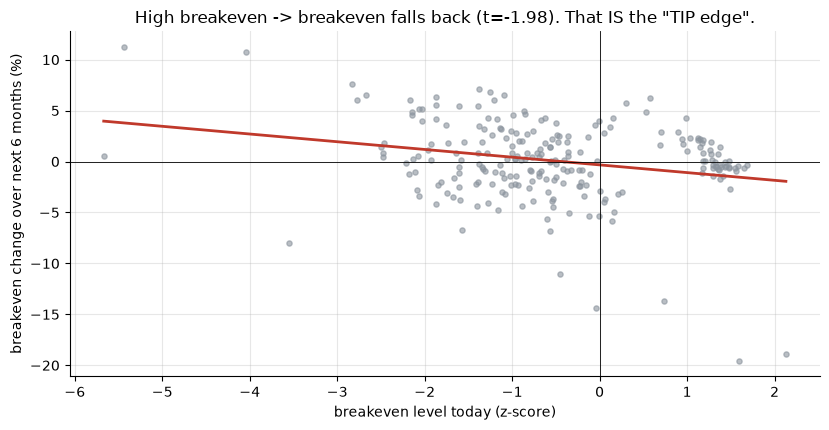

the breakeven proxy predicts its OWN mean reversion at t=-1.98 — not a tradable macro signal


In [4]:
if HAVE_REAL:
    z = st.level_z(BE); fwd_be = BE.shift(-6) - BE
    reg = st.hac_regression(z, fwd_be, lags=6); spt = reg['t']
    df = np.c_[np.asarray(z), np.asarray(fwd_be)]
    df = df[np.isfinite(df).all(1)]
else:
    spt = R['self_pred_t']; rng=np.random.default_rng(381)
    z0 = rng.normal(0,1,200); df = np.c_[z0, -0.008*z0 + rng.normal(0,0.02,200)]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.scatter(df[:,0], df[:,1]*100, s=14, c=GREY, alpha=.6)
b = np.polyfit(df[:,0], df[:,1], 1); xs = np.linspace(df[:,0].min(), df[:,0].max(), 50)
ax.plot(xs, (b[0]*xs+b[1])*100, c=RED, lw=2)
ax.axhline(0, c='k', lw=.6); ax.axvline(0, c='k', lw=.6)
ax.set_xlabel('breakeven level today (z-score)'); ax.set_ylabel('breakeven change over next 6 months (%)')
ax.set_title(f'High breakeven -> breakeven falls back (t={spt:.2f}). That IS the "TIP edge".')
plt.tight_layout(); plt.show()
print(f'the breakeven proxy predicts its OWN mean reversion at t={spt:.2f} — not a tradable macro signal')

There it is: high breakeven simply drifts **back down** (slope is negative, t = -1.98). Since TIP *is* the numerator of our proxy, the 'TIPS edge' is just that mean reversion wearing a macro costume. Strip it away and the TIPS hits are no edge at all.

**The one gold hit is a fluke you can't trade.** The single crossing on an *independent* asset — gold, 3-month change — looks strong (t = −3.21). But it's the **1-in-18 lucky cell**, and the only test that matters is money. Here's that 'signal' traded against just buying gold.

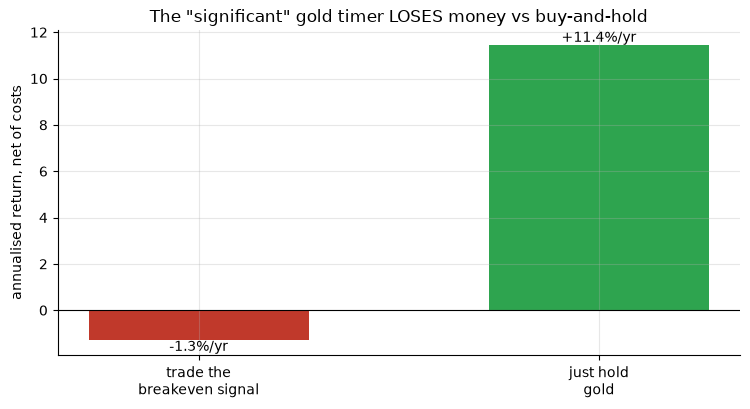

breakeven gold timer: -1.3%/yr net   |   buy-and-hold gold: +11.4%/yr


In [5]:
if HAVE_REAL:
    g = st.sign_timer(M['GLD'], st.change_3m(BE), contrarian=True, cost_bps=10.0)
    net, bh = g['net_ann']*100, g['bh_ann']*100
else:
    net, bh = R['trade'][0][2], R['trade'][0][4]
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['trade the\nbreakeven signal', 'just hold\ngold'], [net, bh], color=[RED, GREEN], width=.55)
for i,v in enumerate([net, bh]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('annualised return, net of costs')
ax.set_title('The "significant" gold timer LOSES money vs buy-and-hold')
plt.tight_layout(); plt.show()
print(f'breakeven gold timer: {net:+.1f}%/yr net   |   buy-and-hold gold: {bh:+.1f}%/yr')

The 'significant' rule earns **-1.3%/yr** after costs; **holding gold** earned **+11%/yr**. A statistically cute regression that loses money is the definition of a mirage.

## 5 · The verdict

- **Signal — Weak.** Breakeven co-moves with assets, and a few regressions look 'significant' — but the only ones that do are the signal predicting *itself* (TIPS) and a single gold fluke. On stocks: nothing. Real as a forecast, weak as a timer.
- **Tradability — Mirage.** Every conditional win-rate is *below* the base rate; the one 'good' rule loses **-1.3%/yr** vs **+11%/yr** buy-and-hold. Nothing deployable.
- **Free macro-timing lunch? — Busted.** Scan a macro number against enough assets and horizons and luck hands you a 'hit.' It's the same trap as the [Fed-Model](../118-fed-model/) and [Real-Rate-Regime](../119-real-rate-regime/) studies.

## 6 · Could you actually trade it? — win-rates vs the base rate

Forget the *t*-stats for a second and ask the operational question: if you bet on the signal, are you right more often than you'd be by just being long the asset? Here are the three headline tests — every conditional win-rate is **below** its base rate.

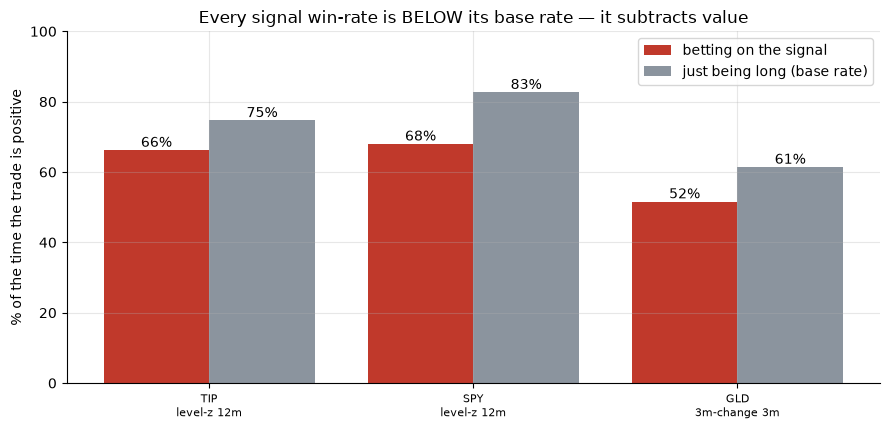

conditional win-rates sit below the base rate -> the signal is worse than naive long


In [6]:
if HAVE_REAL:
    pairs = [('TIP','level-z',12),('SPY','level-z',12),('GLD','3m-change',3)]
    labs, cw, bw = [], [], []
    for asset, sname, h in pairs:
        w = st.directional_winrate(SIGS[sname], st.forward_return(M[asset], h))
        labs.append(f'{asset}\n{sname} {h}m'); cw.append(w['cond_win']*100); bw.append(w['base_win']*100)
else:
    labs = [w[0] for w in R['win']]; cw = [w[1] for w in R['win']]; bw = [w[2] for w in R['win']]
x = np.arange(len(labs))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, cw, .4, color=RED, label='betting on the signal')
ax.bar(x+.2, bw, .4, color=GREY, label='just being long (base rate)')
ax.set_xticks(x); ax.set_xticklabels(labs, fontsize=8); ax.set_ylim(0, 100)
ax.set_ylabel('% of the time the trade is positive')
ax.set_title('Every signal win-rate is BELOW its base rate — it subtracts value')
for i,(c,b) in enumerate(zip(cw,bw)):
    ax.annotate(f'{c:.0f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('conditional win-rates sit below the base rate -> the signal is worse than naive long')

The signal doesn't just fail to add an edge — acting on it makes you **right less often** than simply staying long. That's the operational tell of a non-signal: it's noise dressed as information.

## 7 · Going further 🚪

- **The same trap, other costumes.** [Study 118 — Fed-Model](../118-fed-model/) and [Study 119 — Real-Rate-Regime](../119-real-rate-regime/) regress a macro/valuation number against forward returns — in-sample slopes that look real and out-of-sample edges that vanish.
- **The asset side.** [Study 152 — Inflation-Hedge](../152-inflation-hedge/): do gold and TIPS even *hedge* inflation? The natural complement to 'does breakeven *time* them?'
- **Run it yourself.** Swap the proxy for the real FRED `T10YIE` if you can fetch it, add more assets and horizons — and watch the 'hit count' stay near what luck predicts.

*Think breakeven times the market by more than luck? Pick the asset and horizon **before** you look, trade it net of costs, and show it beating buy-and-hold out-of-sample — then we'll talk.*